# Seminar 6. Machine Translation with RNN

This notebook is based on official PyTorch tutorial: https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html

Dataset link: https://www.kaggle.com/datasets/mohamedlotfy50/wmt-2014-english-german/data

In [ ]:
import numpy as np
import pandas as pd
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from tqdm import tqdm, trange

from torch.utils.data import Dataset, DataLoader


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)

BOS_token = 0
EOS_token = 1
PAD_token = 2
UNK_token = 3


In [ ]:
chunks = pd.read_csv('/kaggle/input/wmt-2014-english-german/wmt14_translate_de-en_train.csv', chunksize=3000, lineterminator='\n')
chunk_idx = random.sample(range(4_000_000//3000), 150)
print(f"First chunk: {min(chunk_idx)}, Last chunk: {max(chunk_idx)}")
df = pd.DataFrame()
for i, chunk in tqdm(enumerate(chunks), total=max(chunk_idx)):
    if i in chunk_idx:
        df = pd.concat([df, chunk.sample(1000, random_state=42)])
        if i == max(chunk_idx):
            break
df


First chunk: 20, Last chunk: 1332


  0%|          | 0/1332 [00:00<?, ?it/s]

,de,en
61801,"Die Zeiten sind in s, es wurden 512 MB (800000...",The times are in s for encrypting 512 MB (8000...
61190,Ich habe mein Angesicht nicht vor Beschämung u...,I hid not my face from b shame and spitting.
61817,Bucht die besten Hostels in Leh über Hostelsclub.,Book the best hostels in Leh with Hostelsclub.
60251,Diese hervorragende Zusammenarbeit sollte über...,This excellent way of cooperating should be ex...
62505,Die Stärke vieler afrikanischer Staaten kann n...,The strength of many African states can only b...
...,...,...
3996618,Es könnte auch mehr Kissen für unvorsichtige F...,"To the same level, in fact, as it did when all..."
3996406,Das Hotel ist ein Mitglied der Hotel- und Gast...,The hotel is a member of the Czech association...
3997157,"Als der Gallier sich sich verbanden, um ihr La...",When the Gallic ones were linked to defend the...
3997068,Cristinas Ehemann hat von diesem außergewöhnli...,"That exceptional spirit benefited her husband,..."


## EDA

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 61801 to 3997133
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   de      150000 non-null  object
 1   en      150000 non-null  object
dtypes: object(2)
memory usage: 3.4+ MB


In [ ]:
df.describe()


,de,en
count,150000,150000
unique,149064,148834
top,Die Aussprache ist geschlossen.,The debate is closed.
freq,119,133


In [ ]:
# df = df.drop_duplicates(subset=['de'])
# df = df.drop_duplicates(subset=['en'])
df = df.drop_duplicates()
df.shape


(149227, 2)

In [ ]:
df['symb_len_de'] = df['de'].apply(len)
df['symb_len_en'] = df['en'].apply(len)
df['word_len_de'] = df['de'].apply(lambda x: len(x.split(' ')))
df['word_len_en'] = df['en'].apply(lambda x: len(x.split(' ')))
df[['symb_len_de', 'symb_len_en', 'word_len_de', 'word_len_en']].describe()


/tmp/ipykernel_55/4230808515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['symb_len_de'] = df['de'].apply(len)
/tmp/ipykernel_55/4230808515.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['symb_len_en'] = df['en'].apply(len)
/tmp/ipykernel_55/4230808515.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

,symb_len_de,symb_len_en,word_len_de,word_len_en
count,149227.000000,149227.000000,149227.000000,149227.000000
mean,152.908884,138.997628,21.410113,23.126867
std,97.731237,110.998270,13.357774,17.036203
min,1.000000,1.000000,1.000000,1.000000
25%,87.000000,80.000000,12.000000,13.000000
50%,133.000000,121.000000,19.000000,20.000000
75%,195.000000,177.000000,27.000000,29.000000
max,9134.000000,20005.000000,1259.000000,2685.000000


/tmp/ipykernel_55/1938516181.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([df['symb_len_en'], df['symb_len_de']],
/tmp/ipykernel_55/1938516181.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df['word_len_en'], df['word_len_de']],


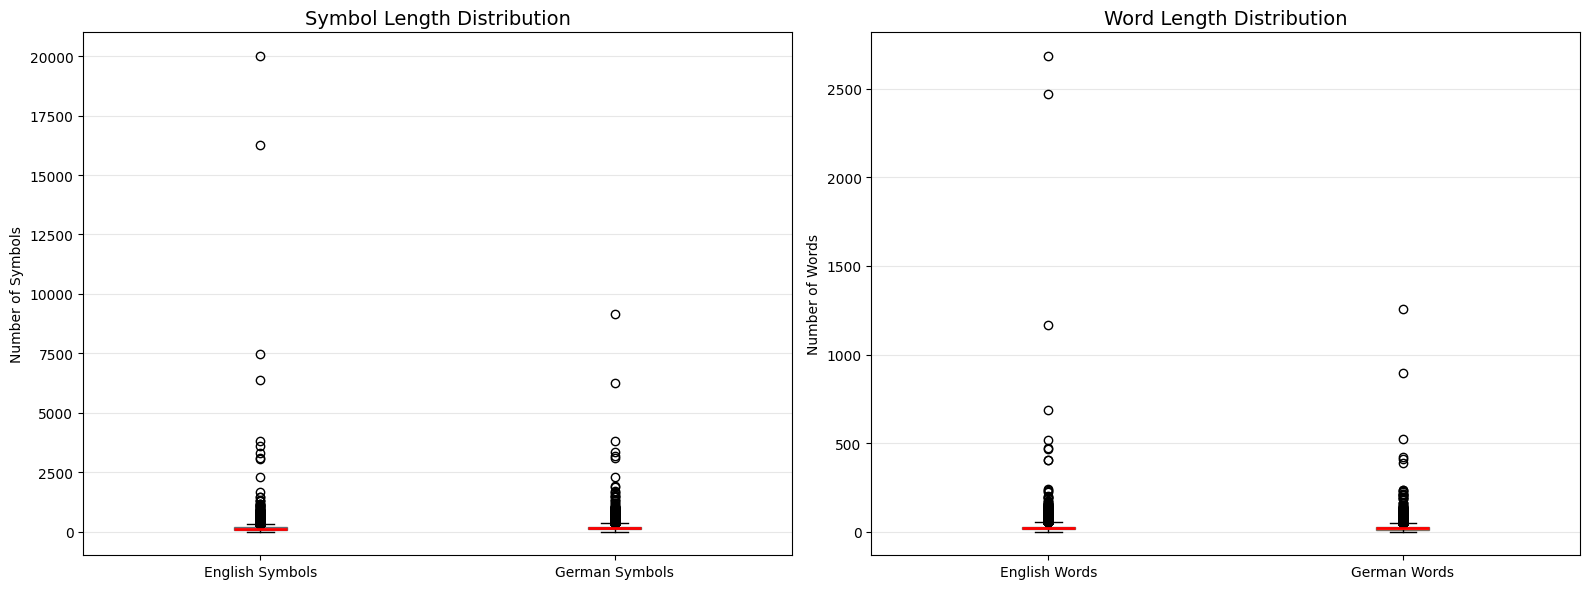

In [ ]:
import matplotlib.pyplot as plt

def plot_boxplots(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Boxplot for symbols
    ax1.boxplot([df['symb_len_en'], df['symb_len_de']], 
                labels=['English Symbols', 'German Symbols'],
                patch_artist=True, 
                boxprops=dict(facecolor='#1f77b4', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
    ax1.set_title('Symbol Length Distribution', fontsize=14)
    ax1.set_ylabel('Number of Symbols')
    ax1.grid(True, axis='y', alpha=0.3)

    # 2. Boxplot for words
    ax2.boxplot([df['word_len_en'], df['word_len_de']], 
                labels=['English Words', 'German Words'],
                patch_artist=True, 
                boxprops=dict(facecolor='#ff7f0e', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_title('Word Length Distribution', fontsize=14)
    ax2.set_ylabel('Number of Words')
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_boxplots(df)


In [ ]:
df_train = df.loc[df['word_len_en'] <= 25].reset_index(drop=True).copy()
df_train.shape


(98750, 6)

In [ ]:
df_train[['de', 'en']].sample(5, random_state=42).values


array([['(RO) In der Republik Moldau finden am 5. April Wahlen statt.',
        '(RO) Elections are taking place in the Republic of Moldova on 5 April.'],
       ['Weine: Vitovska IGT (2004-2005), Malvasia DOC (2004-2005), Kraška črnina/Rosso Carso DOC (2004-2005).',
        'Wines: Vitovska IGT 2004-2005, Malvazija DOC 2004-2005. Kraška črnina (Carso Red) Doc 2004-2005.'],
       ['Der Börsengang dieser Unternehmen – auch wenn es sich um etablierte Firmen handelt – liegt nicht länger als zehn Jahre zurück.',
        'The GEX includes German companies that are listed in the Prime Standard segment of FWB Frankfurter Wertpapierbörse, the Frankfurt Stock Exchange.'],
       ['Im Hinblick auf den Entlastungsbeschluss für den Rat möchte ich sagen, dass wir an den Bemerkungen und der Entscheidung des Ausschusses festhalten.',
        "With regard to the discharge decision where the Council is concerned, I should like to say that we stand by the committee's observations and decision."],
     

## Preprocessing

Examples demonstrate that there are problems with encoding. Additionally, we want to have punctuation as separate tokens, so let's preprocess our texts.

In [ ]:
import unicodedata


In [ ]:
def normalize_string(s):
    # Fix broken encoding, lowercase, strip
    s = unicodedata.normalize('NFC', s.lower().strip())
    # Fix found unrecognized symbol
    s = s.replace('\ufffd', 'ü') 
    # Separate punctuation marks
    s = re.sub(r"([\.!?,])", r" \1 ", s)
    # And remove any other symbols
    s = re.sub(r"[^a-zäöüß\.!?,]+", r" ", s)
    s = re.sub(r"\s+", r" ", s)
    return s.strip()


In [ ]:
df_train['de'] = df_train['de'].apply(normalize_string)
df_train['en'] = df_train['en'].apply(normalize_string)
df_train.head()


,de,en,symb_len_de,symb_len_en,word_len_de,word_len_en
0,"die zeiten sind in s , es wurden mb blöcke mit...",the times are in s for encrypting mb blocks of...,132,117,23,24
1,ich habe mein angesicht nicht vor beschämung u...,i hid not my face from b shame and spitting .,69,44,10,10
2,bucht die besten hostels in leh über hostelscl...,book the best hostels in leh with hostelsclub .,49,46,8,8
3,diese hervorragende zusammenarbeit sollte über...,this excellent way of cooperating should be ex...,96,81,12,13
4,"sukiyaki av , konventionen und anderen erwachs...","sukiyaki av , conventions and other adult site...",91,72,12,12


In [ ]:
df_train[['de', 'en']].sample(5, random_state=42).values


array([['ro in der republik moldau finden am . april wahlen statt .',
        'ro elections are taking place in the republic of moldova on april .'],
       ['weine vitovska igt , malvasia doc , kra ka rnina rosso carso doc .',
        'wines vitovska igt , malvazija doc . kra ka rnina carso red doc .'],
       ['der börsengang dieser unternehmen auch wenn es sich um etablierte firmen handelt liegt nicht länger als zehn jahre zurück .',
        'the gex includes german companies that are listed in the prime standard segment of fwb frankfurter wertpapierbörse , the frankfurt stock exchange .'],
       ['im hinblick auf den entlastungsbeschluss für den rat möchte ich sagen , dass wir an den bemerkungen und der entscheidung des ausschusses festhalten .',
        'with regard to the discharge decision where the council is concerned , i should like to say that we stand by the committee s observations and decision .'],
       ['wir besitzen mehr als terabytes für die speicherung von artikeln

## Vocab

In [ ]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "BOS", 1: "EOS", 2: "PAD", 3: "UNK"}
        self.n_words = 4  # Count system tokens

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

    def trim(self, min_count):
        keep_words = []
        for k, v in self.word2count.items():
            if v >= min_count:
                keep_words.append(k)

        print(f'keep_words {len(keep_words)} / {len(self.word2index)} = {len(keep_words) / len(self.word2index):.4f}')

        # Rebuild vocabs
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "BOS", 1: "EOS", 2: "PAD", 3: "UNK"}
        self.n_words = 4

        for word in keep_words:
            self.addWord(word)


In [ ]:
SOURCE_LANG = 'de'
TARGET_LANG = 'en'

source = Lang(SOURCE_LANG)
target = Lang(TARGET_LANG)

for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    source.addSentence(row['de'])
    target.addSentence(row['en'])

print(f"Source language vocab size: {source.n_words};\nTarget language vocab size: {target.n_words}")


  0%|          | 0/98750 [00:00<?, ?it/s]

Source language vocab size: 128332;
Target language vocab size: 64211


Vocabs are too big, let's throw out rare words

In [ ]:
source.trim(10)
target.trim(10)


keep_words 11608 / 128328 = 0.0905
keep_words 9269 / 64207 = 0.1444


## Test and Val data

Time to get our validation and test sets prepared.

In [ ]:
val_df = pd.read_csv('/kaggle/input/wmt-2014-english-german/wmt14_translate_de-en_validation.csv')
test_df = pd.read_csv('/kaggle/input/wmt-2014-english-german/wmt14_translate_de-en_test.csv')


In [23]:
def clean_and_normalize(df_to_clean, df_train):
    # 1. Apply our normalization function
    df_to_clean['de'] = df_to_clean['de'].apply(normalize_string)
    df_to_clean['en'] = df_to_clean['en'].apply(normalize_string)
    # 2. Remove duplicates in subset
    df_to_clean = df_to_clean.drop_duplicates(subset=['de'])
    df_to_clean = df_to_clean.drop_duplicates(subset=['en'])
    # 3. Remove texts which are present in training set
    train_pairs = set(zip(df_train['de'], df_train['en']))
    mask = df_to_clean.apply(lambda row: (row['de'], row['en']) not in train_pairs, axis=1)
    df_to_clean = df_to_clean[mask]
    
    return df_to_clean
    

In [ ]:
val_df = clean_and_normalize(val_df, df_train)
test_df = clean_and_normalize(test_df, df_train)

print(f"Val size: {len(val_df)}, Test size: {len(test_df)}")


Val size: 2991, Test size: 3001


## Data set\loader

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_lang, trg_lang):
        self.data = dataframe
        self.src_lang = src_lang
        self.trg_lang = trg_lang

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # indexate everything (and add BOS with EOS)
        src_idxs = [0] + [self.src_lang.word2index.get(w, 3) for w in row['de'].split()] + [1]
        trg_idxs = [0] + [self.trg_lang.word2index.get(w, 3) for w in row['en'].split()] + [1]
        
        return torch.tensor(src_idxs, dtype=torch.long), torch.tensor(trg_idxs, dtype=torch.long)


In [ ]:
train_dataset = TranslationDataset(df_train, source, target)
val_dataset = TranslationDataset(val_df, source, target)
test_dataset = TranslationDataset(test_df, source, target)


In [ ]:
from torch.nn.utils.rnn import pad_sequence


In [28]:
def collate_fn(batch):
    src_batch, trg_batch = [], []
    for src_sample, trg_sample in batch:
        src_batch.append(src_sample)
        trg_batch.append(trg_sample)
    
    # padding_value=2 (PAD token)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=2)
    trg_batch = pad_sequence(trg_batch, batch_first=True, padding_value=2)
    
    return src_batch, trg_batch


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


## RNN

In [ ]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=2)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input_seq):
        # input_seq: [batch_size, seq_len]
        embedded = self.dropout(self.embedding(input_seq))
        output, hidden = self.gru(embedded)
        # output: all hidden states (needed for attention)
        # hidden: last hidden state (context vector)
        return output, hidden


In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, query, values):
        # query: hidden state of decoder [1, batch, hidden]
        # values: encoder's output [batch, seq_len, hidden]
        
        query = query.transpose(0, 1) # [batch, 1, hidden]
        
        # count scores
        score = self.V(torch.tanh(self.W1(query) + self.W2(values)))
        # score: [batch, seq_len, 1]

        attention_weights = F.softmax(score, dim=1)
        
        # Context vector (weighted summ of encoder's outputs)
        context_vector = torch.bmm(attention_weights.transpose(1, 2), values)
        # context_vector: [batch, 1, hidden]

        return context_vector, attention_weights


In [ ]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=2)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input_step, hidden, encoder_outputs):
        # input_step: [batch, 1] (текущее слово)
        # hidden: [1, batch, hidden]
        # encoder_outputs: [batch, seq_len, hidden]
        
        embedded = self.dropout(self.embedding(input_step)) # [batch, 1, hidden]

        # Count attention
        context_vector, attn_weights = self.attention(hidden, encoder_outputs)

        # Concat current word vector with context vector
        rnn_input = torch.cat((embedded, context_vector), dim=2) # [batch, 1, hidden*2]

        output, hidden = self.gru(rnn_input, hidden)
        
        logits = self.out(output) # [batch, 1, output_size]
        return logits, hidden, attn_weights


## Training

In [ ]:
def train_epoch(loader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, device, teacher_forcing_ratio=0.5):
    encoder.train()
    decoder.train()
    total_loss = 0

    for src, trg in tqdm(loader, desc='Train'):
        src, trg = src.to(device), trg.to(device)
        # src: [batch, src_len], trg: [batch, trg_len]
        
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, hidden = encoder(src)
        
        batch_size = src.size(0)
        trg_len = trg.size(1)
        
        # Start with BOS token
        decoder_input = torch.tensor([[0]] * batch_size, device=device)
        
        loss = 0
        for t in range(1, trg_len):
            output, hidden, _ = decoder(decoder_input, hidden, encoder_outputs)
            
            # Masked loss calculation (ignoring padding via ignore_index in criterion)
            loss += criterion(output.squeeze(1), trg[:, t])
            
            # Teacher forcing logic
            use_teacher_forcing = random.random() < teacher_forcing_ratio
            if use_teacher_forcing:
                decoder_input = trg[:, t].unsqueeze(1) # Ground truth
            else:
                top1 = output.argmax(2) 
                decoder_input = top1.detach() # Model's own prediction

        loss.backward()
        
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        
        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item() / trg_len

    return total_loss / len(loader)


In [ ]:
def evaluate_epoch(loader, encoder, decoder, criterion, device):
    encoder.eval()
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in tqdm(loader, desc="Validation"):
            src, trg = src.to(device), trg.to(device)
            
            encoder_outputs, hidden = encoder(src)
            batch_size = src.size(0)
            trg_len = trg.size(1)
            
            decoder_input = torch.tensor([[0]] * batch_size, device=device)
            
            loss = 0
            for t in range(1, trg_len):
                output, hidden, _ = decoder(decoder_input, hidden, encoder_outputs)
                loss += criterion(output.squeeze(1), trg[:, t])
                
                # No teacher forcing during validation!
                top1 = output.argmax(2)
                decoder_input = top1.detach()

            total_loss += loss.item() / trg_len

    return total_loss / len(loader)


  0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/1546 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 4.8709 | Val Loss: 6.4577


Train:   0%|          | 0/1546 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 9 | Train Loss: 3.4970 | Val Loss: 6.5588


Train:   0%|          | 0/1546 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 3.4447 | Val Loss: 6.7561


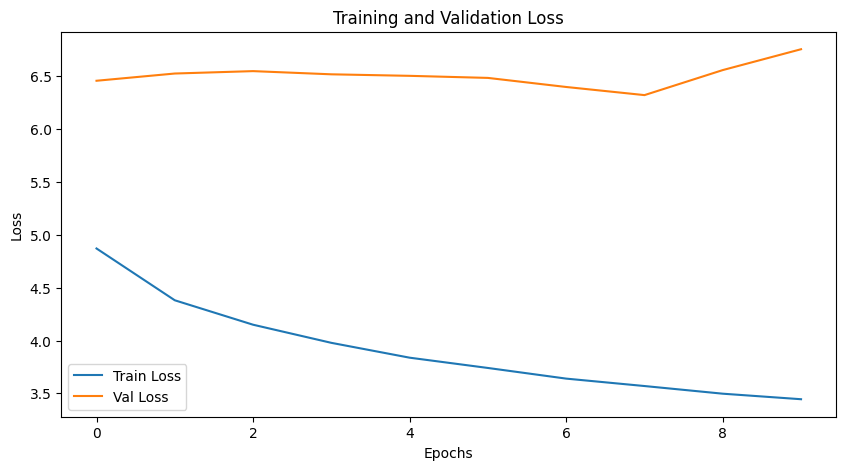

In [ ]:
# Initialization
HIDDEN_SIZE = 256
LEARNING_RATE = 0.001

encoder = EncoderRNN(source.n_words, HIDDEN_SIZE).to(device)
decoder = AttnDecoderRNN(HIDDEN_SIZE, target.n_words).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=2) # Ignore PAD_token
# We use two separate optimizers for Encoder and Decoder
enc_optim = optim.Adam(encoder.parameters(), lr=LEARNING_RATE)
dec_optim = optim.Adam(decoder.parameters(), lr=LEARNING_RATE)

enc_best_state = encoder.state_dict().copy()
dec_best_state = decoder.state_dict().copy()

train_losses = []
val_losses = []
min_val_loss = 100

for epoch in trange(10): # 10 epochs
    train_loss = train_epoch(train_loader, encoder, decoder, enc_optim, dec_optim, criterion, device)
    val_loss = evaluate_epoch(val_loader, encoder, decoder, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        enc_best_state = encoder.state_dict().copy()
        dec_best_state = decoder.state_dict().copy()
    
    print(f'Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

encoder.load_state_dict(enc_best_state)
decoder.load_state_dict(dec_best_state)

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Okay, let's count BLEU score

In [ ]:
!pip install evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


In [ ]:
import evaluate


2026-02-04 10:35:30.245136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770201330.398205      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770201330.441206      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770201330.797016      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770201330.797055      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770201330.797058      55 computation_placer.cc:177] computation placer alr

In [ ]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index.get(word, 3) for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.insert(0, 0) # Add BOS token at beginning
    indexes.append(1) # EOS_token
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


In [ ]:
def translate_sentence(sentence, encoder, decoder, source_lang, target_lang, device, max_len=50):
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():
        # Preprocess input
        input_tensor = tensorFromSentence(source_lang, normalize_string(sentence)).view(1, -1).to(device)
        src_len = input_tensor.size(1)
        
        encoder_outputs, hidden = encoder(input_tensor)

        # Decoder's first input (BOS)
        decoder_input = torch.tensor([[0]], device=device)
        
        decoded_words = []
        decoder_attentions = torch.zeros(max_len, src_len)

        for di in range(max_len):
            logits, hidden, attn_weights = decoder(decoder_input, hidden, encoder_outputs)

            # repetition penalty
            if len(decoded_words) > 0:
                last_idx = target_lang.word2index.get(decoded_words[-1], -1)
                if last_idx != -1:
                    logits[0, 0, last_idx] -= 2.0
            
            # Save attention weights for visualization
            weights_flat = attn_weights.view(-1).cpu()
            decoder_attentions[di] = weights_flat
            
            top1 = logits.argmax(2)
            
            if top1.item() == 1: # EOS_token
                break
            else:
                decoded_words.append(target_lang.index2word[top1.item()])
            
            decoder_input = top1.detach()

        return decoded_words, decoder_attentions[:len(decoded_words), :]


In [ ]:
sent = 'Komm tanzen. Ich will nicht.'
translation, attn = translate_sentence(sent, encoder, decoder, source, target, device)
print(' '.join(translation))


i do not want .


In [ ]:
def get_bleu_score(df_test, encoder, decoder, source_lang, target_lang, device, n_samples=500):
    bleu = evaluate.load('bleu')
    
    candidate_corpus = []
    references_corpus = []

    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Calculating BLEU"):
        src_sentence = row['de']
        trg_sentence = row['en']
        
        decoded_words, _ = translate_sentence(src_sentence, encoder, decoder, source_lang, target_lang, device)
        
        # Remove EOS token from translation
        if decoded_words and decoded_words[-1] == 'EOS':
            decoded_words = decoded_words[:-1]
            
        candidate_corpus.append(' '.join(decoded_words))
        references_corpus.append([trg_sentence])
    print(candidate_corpus[:10])
    print(references_corpus[:10])
        
    score = bleu.compute(predictions=candidate_corpus, references=references_corpus)
    return score


In [ ]:
test_bleu = get_bleu_score(test_df, encoder, decoder, source, target, device)
test_bleu


Calculating BLEU:   0%|          | 0/3001 [00:00<?, ?it/s]

['originally , the UNK , even though , have been UNK in the years .', 'they will be to be UNK , UNK , UNK , UNK , UNK .', 'they are not all UNK UNK , but , and , and , and , and a UNK and a UNK .', 'in the , UNK , the UNK authorities have a the UNK of the cooperation with the situation in recent decades .', 'UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK UNK .', 'UNK UNK UNK UNK UNK UNK , UNK UNK UNK UNK UNK', 'more safety for', 'UNK UNK UNK UNK the UNK UNK the situation of the situation .', 'at the time , i am money and money .', 'this year are UNK UNK the last year .']
[['the school yard renovation was originally planned back in , however , high unplanned expenses meant that the work had to be pushed back .'], ['consequently , they will be particularly motivated playing against their former coach .'], ['they re not all experienced racers , but people looking for excitement and adventure , and an achievable path towards world class events .'], ['the letter

{'bleu': 0.015354044135433079,
 'precisions': [0.31422659534658476,
  0.049470880765514154,
  0.00974979740680713,
  0.0022134776192818495],
 'brevity_penalty': 0.6379798430463788,
 'length_ratio': 0.6899175361064286,
 'translation_length': 45429,
 'reference_length': 65847}

In [ ]:
import matplotlib.ticker as ticker


In [ ]:
def show_attention_map(input_sentence, output_words, attentions):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    input_tokens = normalize_string(input_sentence).split(' ') + ['EOS']
    
    ax.set_xticks(range(len(input_tokens)))
    ax.set_yticks(range(len(output_words)))
    
    ax.set_xticklabels(input_tokens, rotation=90, fontsize=12)
    ax.set_yticklabels(output_words, fontsize=12)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title("Attention Weights (DE -> EN)", pad=20, fontsize=14)
    plt.show()


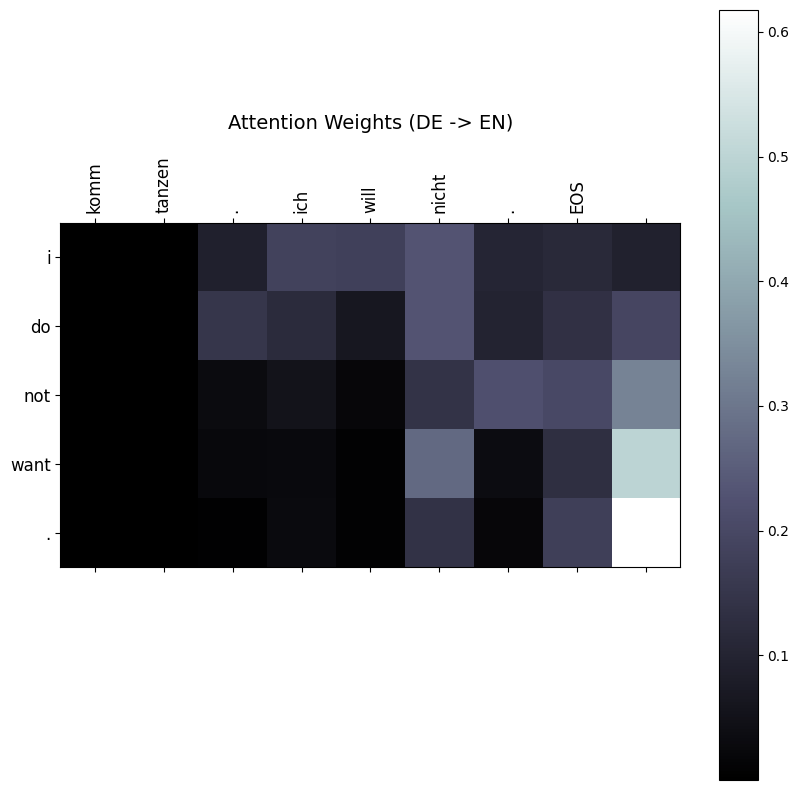

In [ ]:
show_attention_map(sent, translation, attn)
